In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [3]:
# Set the path to your extracted data
#base_path = Path('..//data//raw//fetal_brain')
base_path = Path ('..//data//raw') 

In [4]:
# First, let's see what folders you have
print("📁 Folder structure:")
for folder in base_path.iterdir():
    if folder.is_dir():
        print(f"  - {folder.name}")
        # Check subfolders
        subfolders = list(folder.iterdir())
        if len(subfolders) <= 10:  # Only show if not too many
            for sub in subfolders[:5]:  # Show first 5
                print(f"    └─ {sub.name}")

📁 Folder structure:
  - trans_ventricular
  - trans_ventricular_original


In [5]:
# Path to original ultrasound images
original_path = base_path / 'trans_ventricular_original'
print(f"\n🔍 Checking original images path:")
print(f"   Path: {original_path}")
print(f"   Exists: {original_path.exists()}")

# Path to segmentation masks
mask_path = base_path / 'trans_ventricular/segmentation_mask/SegmentationClass'
print(f"\n🔍 Checking mask path:")
print(f"   Path: {mask_path}")
print(f"   Exists: {mask_path.exists()}")


🔍 Checking original images path:
   Path: ..\data\raw\trans_ventricular_original
   Exists: True

🔍 Checking mask path:
   Path: ..\data\raw\trans_ventricular\segmentation_mask\SegmentationClass
   Exists: True


In [6]:
# SECTION 5: COUNT AND LIST IMAGE FILES
# --------------------------------------
"""
Let's count how many images we have in each folder.
This tells us the size of our dataset.
"""

if original_path.exists():
    # Find all PNG files in the original folder
    original_images = list(original_path.glob('*.png'))
    print(f"\n📸 ULTRASOUND IMAGES:")
    print(f"   Found {len(original_images)} images")
    
    # Show first 3 filenames as examples
    print("   Examples:")
    for img in original_images[:3]:
        print(f"      - {img.name}")

if mask_path.exists():
    # Find all PNG files in the mask folder
    mask_images = list(mask_path.glob('*.png'))
    print(f"\n🎨 SEGMENTATION MASKS:")
    print(f"   Found {len(mask_images)} masks")
    
    # Show first 3 filenames as examples
    print("   Examples:")
    for img in mask_images[:3]:
        print(f"      - {img.name}")


📸 ULTRASOUND IMAGES:
   Found 597 images
   Examples:
      - Patient00188_Plane3_2_of_3.png
      - Patient00216_Plane3_2_of_5.png
      - Patient00305_Plane3_1_of_5.png

🎨 SEGMENTATION MASKS:
   Found 584 masks
   Examples:
      - Patient00188_Plane3_2_of_3.png
      - Patient00216_Plane3_2_of_5.png
      - Patient00305_Plane3_1_of_5.png


In [7]:
# SECTION 6: READ THE LABELMAP
# -----------------------------
"""
The labelmap.txt file tells us what each color in the masks means.
This is CRITICAL - it's our dictionary for understanding the masks.
"""

labelmap_path = base_path / 'trans_ventricular/segmentation_mask/labelmap.txt'
print(f"\n📋 LABEL MAPPING:")
print("=" * 50)

if labelmap_path.exists():
    with open(labelmap_path, 'r') as f:
        content = f.read()
        print(content)
        print("\nInterpretation:")
        print("   Red (255,0,0) = Brain tissue")
        print("   Green (0,255,0) = CSP (Cavum Septum Pellucidum)")
        print("   Blue (0,0,255) = LV (Lateral Ventricles) ← THIS IS WHAT WE WANT!")
        print("   Black (0,0,0) = Background")
else:
    print("❌ Labelmap not found!")



📋 LABEL MAPPING:
# label:color_rgb:parts:actions
Brain:255,0,0::
CSP:0,255,0::
LV:0,0,255::
background:0,0,0::


Interpretation:
   Red (255,0,0) = Brain tissue
   Green (0,255,0) = CSP (Cavum Septum Pellucidum)
   Blue (0,0,255) = LV (Lateral Ventricles) ← THIS IS WHAT WE WANT!
   Black (0,0,0) = Background



🖼️ VISUALIZING SAMPLE DATA:
Image 1:
   Ultrasound shape: (392, 640, 3)
   Mask shape: (661, 959, 3)
Image 2:
   Ultrasound shape: (663, 961, 3)
   Mask shape: (661, 959, 3)
Image 3:
   Ultrasound shape: (787, 1137, 3)
   Mask shape: (661, 959, 3)


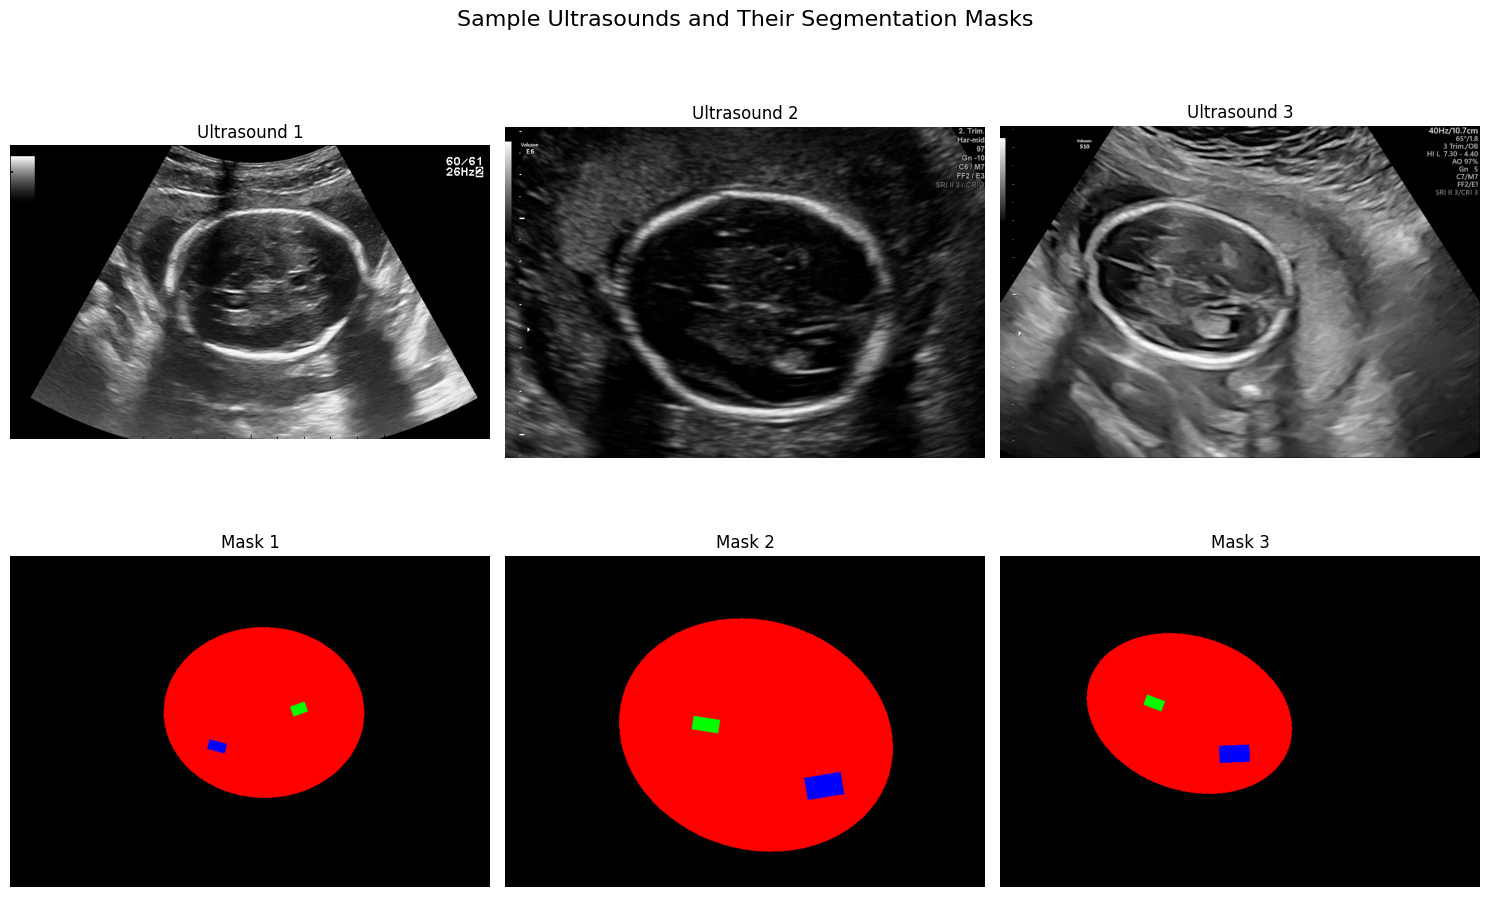

In [9]:
# SECTION 7: DISPLAY SAMPLE IMAGES
# ---------------------------------
"""
Let's actually look at some images to understand our data visually.
We'll show both the ultrasound and its corresponding mask.
"""

print(f"\n🖼️ VISUALIZING SAMPLE DATA:")
print("=" * 50)

if original_images and mask_images:
    # Create a figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Show 3 examples
    for i in range(min(3, len(original_images))):
        # Read original ultrasound image
        orig_img = cv2.imread(str(original_images[i]))
        orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display
        
        # Find corresponding mask (may have different naming pattern)
        img_name = original_images[i].stem.split('_')[0]  # Get patient ID
        matching_masks = [m for m in mask_images if img_name in m.stem]
        
        if matching_masks:
            # Read the mask
            mask_img = cv2.imread(str(matching_masks[0]))
            mask_img_rgb = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)
            
            # Display original image
            axes[0, i].imshow(orig_img_rgb)
            axes[0, i].set_title(f"Ultrasound {i+1}")
            axes[0, i].axis('off')
            
            # Display mask
            axes[1, i].imshow(mask_img_rgb)
            axes[1, i].set_title(f"Mask {i+1}")
            axes[1, i].axis('off')
            
            print(f"Image {i+1}:")
            print(f"   Ultrasound shape: {orig_img.shape}")
            print(f"   Mask shape: {mask_img.shape}")
    
    plt.suptitle("Sample Ultrasounds and Their Segmentation Masks", fontsize=16)
    plt.tight_layout()
    plt.show()


In [10]:
# SECTION 8: ANALYZE MASK COLORS
# -------------------------------
"""
Let's check what colors are actually in the masks.
This confirms our understanding of the labelmap.
"""

print(f"\n🎨 ANALYZING MASK COLORS:")
print("=" * 50)

if mask_images:
    # Read first mask
    sample_mask = cv2.imread(str(mask_images[0]))
    
    # Find unique colors
    # Reshape mask to list of pixels, then find unique RGB values
    pixels = sample_mask.reshape(-1, sample_mask.shape[2])
    unique_colors = np.unique(pixels, axis=0)
    
    print(f"Found {len(unique_colors)} unique colors in first mask:")
    for color in unique_colors:
        # Note: OpenCV uses BGR, so we need to flip to RGB
        b, g, r = color
        print(f"   RGB({r},{g},{b})", end="")
        
        # Identify what this color represents
        if r == 255 and g == 0 and b == 0:
            print(" → Brain tissue")
        elif r == 0 and g == 255 and b == 0:
            print(" → CSP")
        elif r == 0 and g == 0 and b == 255:
            print(" → Lateral Ventricles (LV)")
        elif r == 0 and g == 0 and b == 0:
            print(" → Background")
        else:
            print(" → Unknown")



🎨 ANALYZING MASK COLORS:
Found 4 unique colors in first mask:
   RGB(0,0,0) → Background
   RGB(255,0,0) → Brain tissue
   RGB(0,255,0) → CSP
   RGB(0,0,255) → Lateral Ventricles (LV)



🔍 EXTRACTING VENTRICLES:


IndexError: boolean index did not match indexed array along axis 0; size of axis is 392 but size of corresponding boolean axis is 661

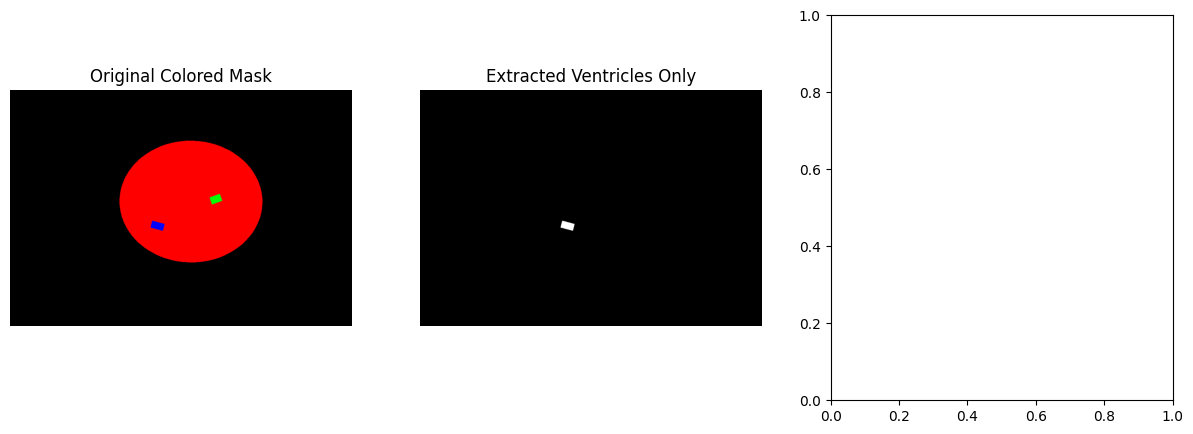

In [12]:
# SECTION 9: EXTRACT AND VISUALIZE VENTRICLES ONLY
# --------------------------------------------------
"""
Since we care about ventricles (blue pixels), let's extract just those.
This shows what our model will be trying to learn.
"""

print(f"\n🔍 EXTRACTING VENTRICLES:")
print("=" * 50)

if mask_images:
    # Read a mask
    mask = cv2.imread(str(mask_images[0]))
    
    # Extract only blue pixels (ventricles)
    # Blue in BGR format means B=255, G=0, R=0
    ventricle_mask = (
        (mask[:,:,0] == 255) &  # Blue channel = 255
        (mask[:,:,1] == 0) &     # Green channel = 0
        (mask[:,:,2] == 0)       # Red channel = 0
    )
    
    # Convert boolean mask to image (0 or 255)
    ventricle_image = ventricle_mask.astype(np.uint8) * 255
    
    # Display
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
    plt.title("Original Colored Mask")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(ventricle_image, cmap='gray')
    plt.title("Extracted Ventricles Only")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    # Overlay ventricles on original
    if original_images:
        orig = cv2.imread(str(original_images[0]))
        orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        overlay = orig_rgb.copy()
        overlay[ventricle_mask] = [0, 0, 255]  # Color ventricles blue
        plt.imshow(overlay)
        plt.title("Ventricles Overlaid on Ultrasound")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate ventricle statistics
    ventricle_pixels = np.sum(ventricle_mask)
    total_pixels = ventricle_mask.size
    ventricle_percentage = (ventricle_pixels / total_pixels) * 100
    
    print(f"Ventricle Statistics:")
    print(f"   Ventricle pixels: {ventricle_pixels:,}")
    print(f"   Total pixels: {total_pixels:,}")
    print(f"   Ventricle percentage: {ventricle_percentage:.2f}%")

In [14]:
# SECTION 10: SUMMARY
# --------------------
"""
Final summary of what we found in our dataset.
"""

print(f"\n📊 DATASET SUMMARY:")
print("=" * 50)
print(f"✅ Ultrasound images: {len(original_images) if 'original_images' in locals() else 0}")
print(f"✅ Segmentation masks: {len(mask_images) if 'mask_images' in locals() else 0}")
print(f"✅ Classes: Brain (red), CSP (green), Ventricles (blue), Background (black)")
print(f"✅ Our target: Ventricles (blue pixels)")


📊 DATASET SUMMARY:
✅ Ultrasound images: 597
✅ Segmentation masks: 584
✅ Classes: Brain (red), CSP (green), Ventricles (blue), Background (black)
✅ Our target: Ventricles (blue pixels)
